## Dataset Background

### Source
The dataset is sourced from Kaggle, *100,000 Diabetes Clinical Dataset* by Priyam Choksi. It contains anonymized clinical records aggregated from U.S. electronic health systems across 53 states and territories.

Link: https://www.kaggle.com/datasets/priyamchoksi/100000-diabetes-clinical-dataset/data


The dataset is structured for large-scale analysis of diabetes risk factors and reflects population-level clinical observations rather than longitudinal patient tracking (i.e., each row is an independent record, not a follow-up visit).


### Imports

In [35]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

COLORS = ["#4C72B0", "#DD8452"]  # blue = no diabetes, orange = diabetes

IMAGES_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "images")
os.makedirs(IMAGES_DIR, exist_ok=True)
print("Images will be saved to:", IMAGES_DIR)

raw = pd.read_csv("../../data/raw_data/diabetes_dataset.csv")

Images will be saved to: /Users/swornimbasnet/Desktop/sjsu/sp2026/cs131/Team10-ComprehensiveDiabetesClinicalDataset-health/diabetes_pipeline/visualization/images


### DATA CARD SECTION

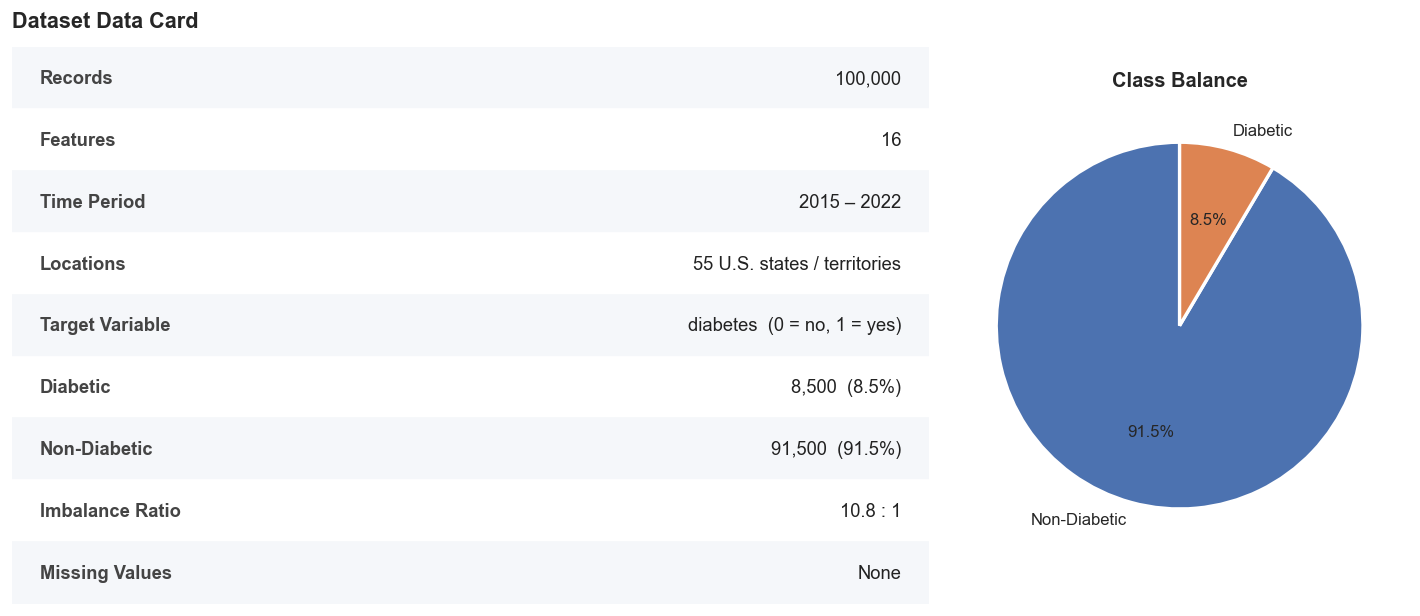

In [36]:
diabetic_count     = int(raw["diabetes"].sum())
non_diabetic_count = len(raw) - diabetic_count
year_min, year_max = int(raw["year"].min()), int(raw["year"].max())
n_locations        = raw["location"].nunique()

rows = [
    ("Records",          f"{len(raw):,}"),
    ("Features",         str(raw.shape[1])),
    ("Time Period",      f"{year_min} – {year_max}"),
    ("Locations",        f"{n_locations} U.S. states / territories"),
    ("Target Variable",  "diabetes  (0 = no, 1 = yes)"),
    ("Diabetic",         f"{diabetic_count:,}  ({diabetic_count/len(raw)*100:.1f}%)"),
    ("Non-Diabetic",     f"{non_diabetic_count:,}  ({non_diabetic_count/len(raw)*100:.1f}%)"),
    ("Imbalance Ratio",  f"{non_diabetic_count/diabetic_count:.1f} : 1"),
    ("Missing Values",   "None"),
]

fig, (ax_card, ax_pie) = plt.subplots(1, 2, figsize=(12, len(rows) * 0.5 + 0.8),
                                       gridspec_kw={"width_ratios": [2, 1]})

# Data card table
ax_card.axis("off")
for i, (label, value) in enumerate(rows):
    bg = "#f5f7fa" if i % 2 == 0 else "white"
    ax_card.add_patch(plt.Rectangle((0, i), 1, 1, transform=ax_card.transData,
                                     color=bg, zorder=0))
    ax_card.text(0.03, i + 0.5, label, va="center", ha="left",
                 fontsize=11, fontweight="bold", color="#444")
    ax_card.text(0.97, i + 0.5, value, va="center", ha="right",
                 fontsize=11, color="#222")
ax_card.set_xlim(0, 1)
ax_card.set_ylim(0, len(rows))
ax_card.invert_yaxis()
ax_card.set_title("Dataset Data Card", fontsize=13, fontweight="bold", pad=12, loc="left")

# Pie chart
ax_pie.pie(
    [non_diabetic_count, diabetic_count],
    labels=["Non-Diabetic", "Diabetic"],
    autopct="%1.1f%%",
    colors=COLORS,
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10)
)
ax_pie.set_title("Class Balance", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "data_card.png"), bbox_inches="tight")
plt.show()

### Time Period Analysis
Records span **2015 to 2022**, covering **100,000 patients** distributed across all collection years. 

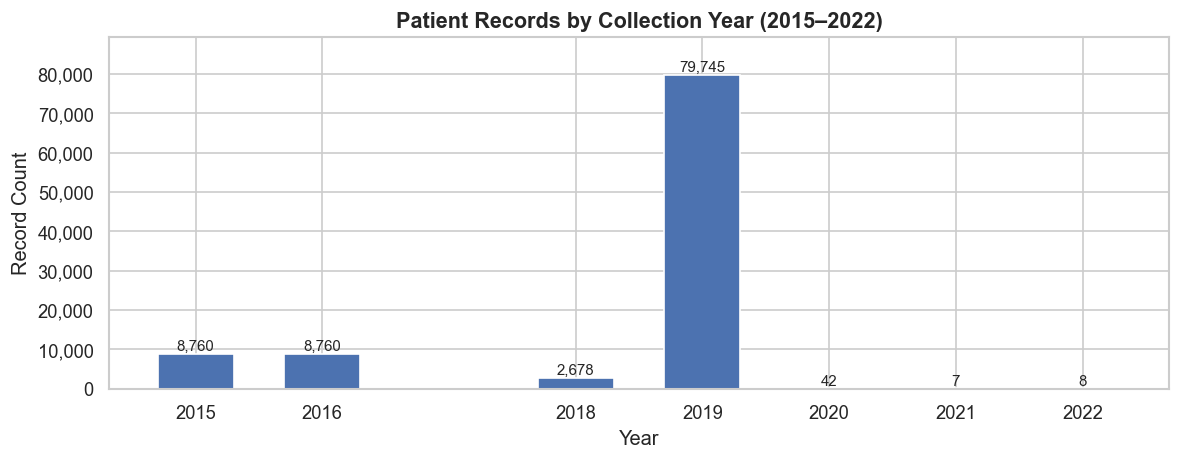

2015     8760
2016     8760
2018     2678
2019    79745
2020       42
2021        7
2022        8


In [37]:
year_counts = raw["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(year_counts.index, year_counts.values, color="#4C72B0", edgecolor="white", width=0.6)
for bar, n in zip(bars, year_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f"{n:,}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Patient Records by Collection Year (2015–2022)", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Record Count")
ax.set_xticks(year_counts.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, year_counts.max() * 1.12)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "records_by_year.png"), bbox_inches="tight")
plt.show()

print(year_counts.to_string(header=False))

Records are heavily concentrated around 2019, with uneven distribution across other years. This makes the dataset unsuitable for time-based trend analysis.

## 2. Key Variables

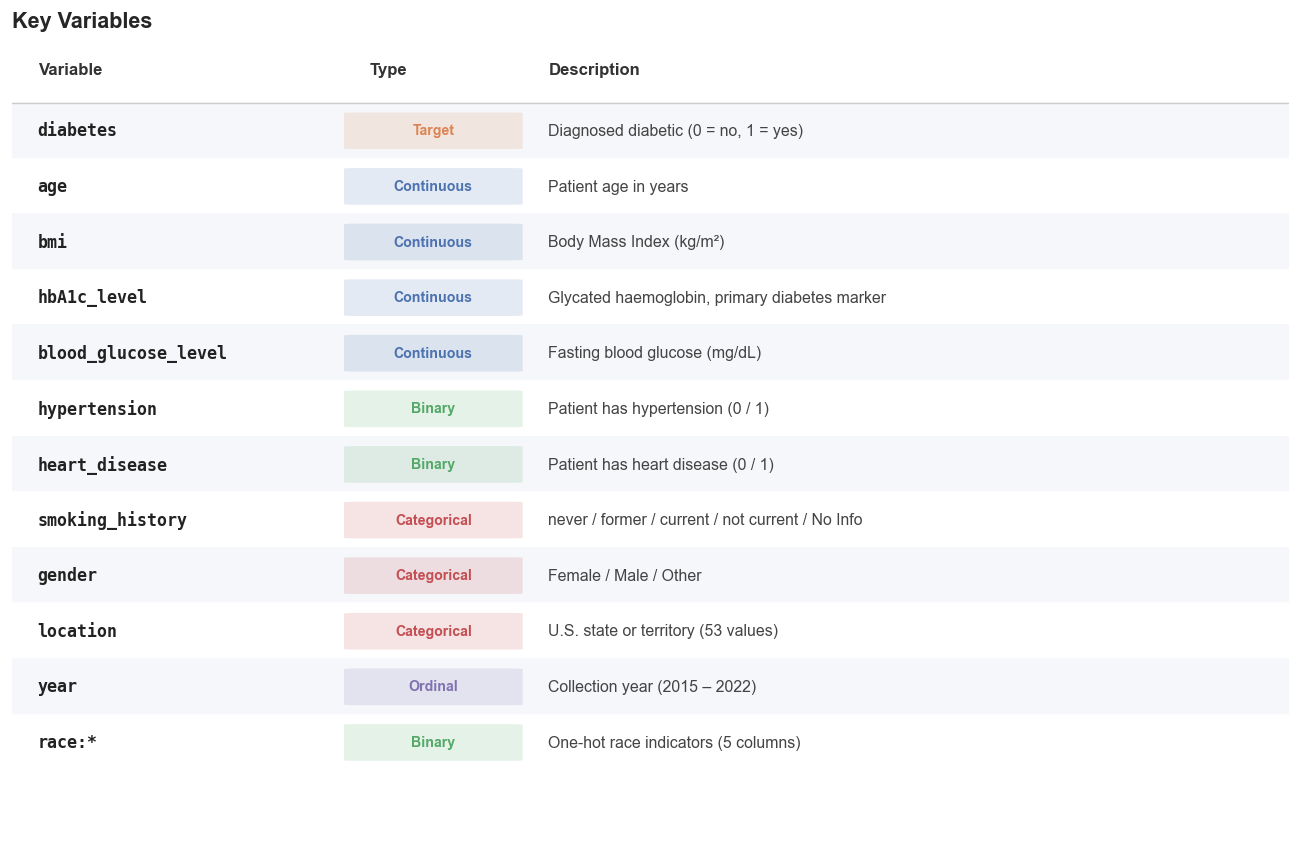

In [38]:
from matplotlib.patches import Rectangle, FancyBboxPatch

TYPE_COLORS = {
    "Target":      "#DD8452",
    "Continuous":  "#4C72B0",
    "Binary":      "#55A868",
    "Categorical": "#C44E52",
    "Ordinal":     "#8172B2",
}

variables = [
    ("diabetes",             "Target",      "Diagnosed diabetic (0 = no, 1 = yes)"),
    ("age",                  "Continuous",  "Patient age in years"),
    ("bmi",                  "Continuous",  "Body Mass Index (kg/m²)"),
    ("hbA1c_level",          "Continuous",  "Glycated haemoglobin, primary diabetes marker"),
    ("blood_glucose_level",  "Continuous",  "Fasting blood glucose (mg/dL)"),
    ("hypertension",         "Binary",      "Patient has hypertension (0 / 1)"),
    ("heart_disease",        "Binary",      "Patient has heart disease (0 / 1)"),
    ("smoking_history",      "Categorical", "never / former / current / not current / No Info"),
    ("gender",               "Categorical", "Female / Male / Other"),
    ("location",             "Categorical", "U.S. state or territory (53 values)"),
    ("year",                 "Ordinal",     "Collection year (2015 – 2022)"),
    ("race:*",               "Binary",      "One-hot race indicators (5 columns)"),
]

fig, ax = plt.subplots(figsize=(11, len(variables) * 0.52 + 1.0))
ax.axis("off")

for x, header in [(0.02, "Variable"), (0.28, "Type"), (0.42, "Description")]:
    ax.text(x, len(variables) + 0.6, header, va="center", ha="left",
            fontsize=10, fontweight="bold", color="#333")

ax.axhline(len(variables), color="#ccc", linewidth=0.8)

for i, (var, vtype, desc) in enumerate(variables):
    row = len(variables) - 1 - i
    bg = "#f5f7fa" if i % 2 == 0 else "white"
    ax.add_patch(Rectangle((0, row), 1, 1, transform=ax.transData,
                            color=bg, zorder=0))
    ax.text(0.02, row + 0.5, var, va="center", ha="left",
            fontsize=10, fontweight="bold", color="#222",
            fontfamily="monospace")
    color = TYPE_COLORS.get(vtype, "#888")
    ax.add_patch(FancyBboxPatch((0.27, row + 0.18), 0.12, 0.64,
                                 boxstyle="round,pad=0.01",
                                 linewidth=0, color=color, alpha=0.15,
                                 transform=ax.transData, zorder=1))
    ax.text(0.33, row + 0.5, vtype, va="center", ha="center",
            fontsize=8.5, color=color, fontweight="bold", zorder=2)
    ax.text(0.42, row + 0.5, desc, va="center", ha="left",
            fontsize=9.5, color="#444")

ax.set_xlim(0, 1)
ax.set_ylim(-1.2, len(variables) + 1)
ax.set_title("Key Variables", fontsize=13, fontweight="bold", pad=12, loc="left")

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "key_variables.png"), bbox_inches="tight")
plt.show()

## 3. Numeric Feature Distributions by Class

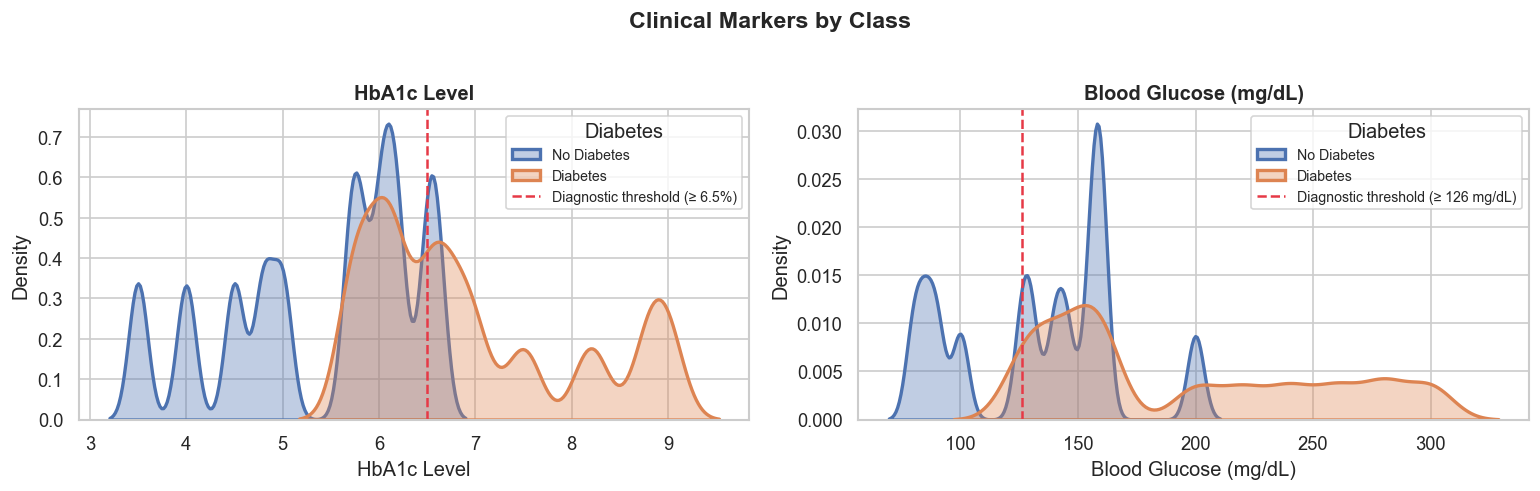

In [39]:
features = [
    ("hbA1c_level",         "HbA1c Level",          6.5,  "Diagnostic threshold (≥ 6.5%)"),
    ("blood_glucose_level", "Blood Glucose (mg/dL)", 126,  "Diagnostic threshold (≥ 126 mg/dL)"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (col, label, threshold, threshold_label) in zip(axes, features):
    for val, name, color in [(0, "No Diabetes", COLORS[0]), (1, "Diabetes", COLORS[1])]:
        sns.kdeplot(
            raw[raw["diabetes"] == val][col],
            ax=ax, label=name, color=color,
            fill=True, alpha=0.35, linewidth=2
        )
    ax.axvline(threshold, color="#e63946", linewidth=1.5,
               linestyle="--", label=threshold_label)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend(title="Diabetes", fontsize=8.5)

plt.suptitle("Clinical Markers by Class", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "numeric_distributions.png"), bbox_inches="tight")
plt.show()

**Why these features were excluded from the model**

`hbA1c_level` and `blood_glucose_level` are the clinical diagnostic criteria for diabetes.
 An HbA1c ≥ 6.5% or fasting glucose ≥ 126 mg/dL is how the `diabetes` label is assigned. Including them as model features would be **data leakage**: the model would simply learn the diagnostic threshold rather than any meaningful risk pattern.


The pipeline is intentionally built on **demographic and comorbidity features** information available before a lab test is ordered. This makes the model useful as a population-level screening tool, not just a restatement of the diagnosis.

## 4. Model Features - `final_df`

The preprocessing step (`01_preprocessing.ipynb`) narrows the original 16-column dataset down to a 6-column **skinny table**, the direct input to the ML pipeline.

The selected features represent risk factors that are observable **without a lab test**: age group, BMI, and the presence of comorbidities (hypertension and heart disease). This keeps the model grounded in demographic and clinical history rather than diagnostic markers, making it viable as a pre-screening tool.

| Column | Role |
|---|---|
| `age_bucket` | Bucketed age group: children / youth / adult / senior |
| `bmi` | Raw BMI value |
| `bmi_category` | Bucketed BMI: underweight / healthy / overweight / obese |
| `hypertension` | Binary comorbidity flag |
| `heart_disease` | Binary comorbidity flag |
| `diabetes` | Target label (0 / 1) |

In [40]:
import pyarrow.parquet as pq

df = pq.read_table("../../data/final_df/", use_pandas_metadata=False).to_pandas()

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes.to_string()}")

Shape: 99,991 rows × 6 columns

Columns: ['age_bucket', 'bmi', 'bmi_category', 'hypertension', 'heart_disease', 'diabetes']

Dtypes:
age_bucket           str
bmi              float64
bmi_category         str
hypertension       int32
heart_disease      int32
diabetes           int32


### 4.1 Diabetes Prevalence by Age Group

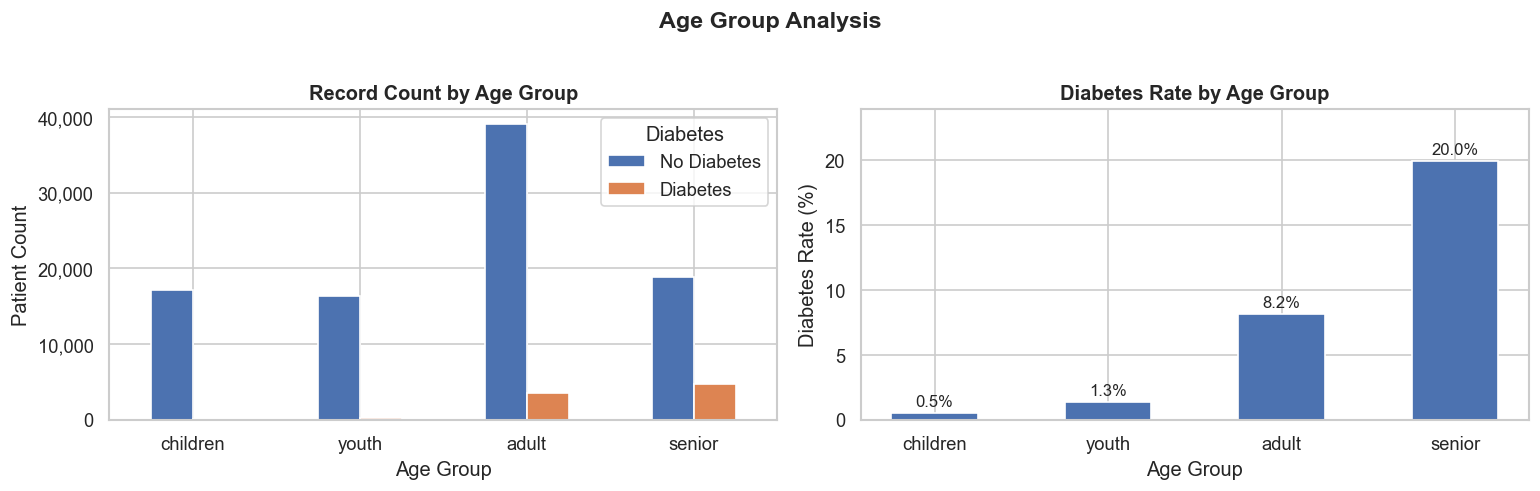

            total  diabetic       rate
age_bucket                            
children    17217        82   0.476273
youth       16513       219   1.326228
adult       42630      3477   8.156228
senior      23631      4719  19.969532


In [41]:
age_order = ["children", "youth", "adult", "senior"]

age_stats = (
    df.groupby("age_bucket")["diabetes"]
    .agg(total="count", diabetic="sum")
    .reindex(age_order)
)
age_stats["rate"] = age_stats["diabetic"] / age_stats["total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: grouped bar — counts per class
ct = df.groupby(["age_bucket", "diabetes"]).size().unstack(fill_value=0).reindex(age_order)
ct.columns = ["No Diabetes", "Diabetes"]
ct.plot(kind="bar", ax=axes[0], color=COLORS, edgecolor="white", rot=0)
axes[0].set_title("Record Count by Age Group", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Patient Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend(title="Diabetes")

# Right: diabetes rate per age group
bars = axes[1].bar(age_order, age_stats["rate"], color="#4C72B0", edgecolor="white", width=0.5)
for bar, rate in zip(bars, age_stats["rate"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{rate:.1f}%", ha="center", va="bottom", fontsize=10)
axes[1].set_title("Diabetes Rate by Age Group", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Diabetes Rate (%)")
axes[1].set_ylim(0, age_stats["rate"].max() * 1.2)

plt.suptitle("Age Group Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "age_analysis.png"), bbox_inches="tight")
plt.show()

print(age_stats.to_string())

### 4.2 Diabetes Prevalence by BMI

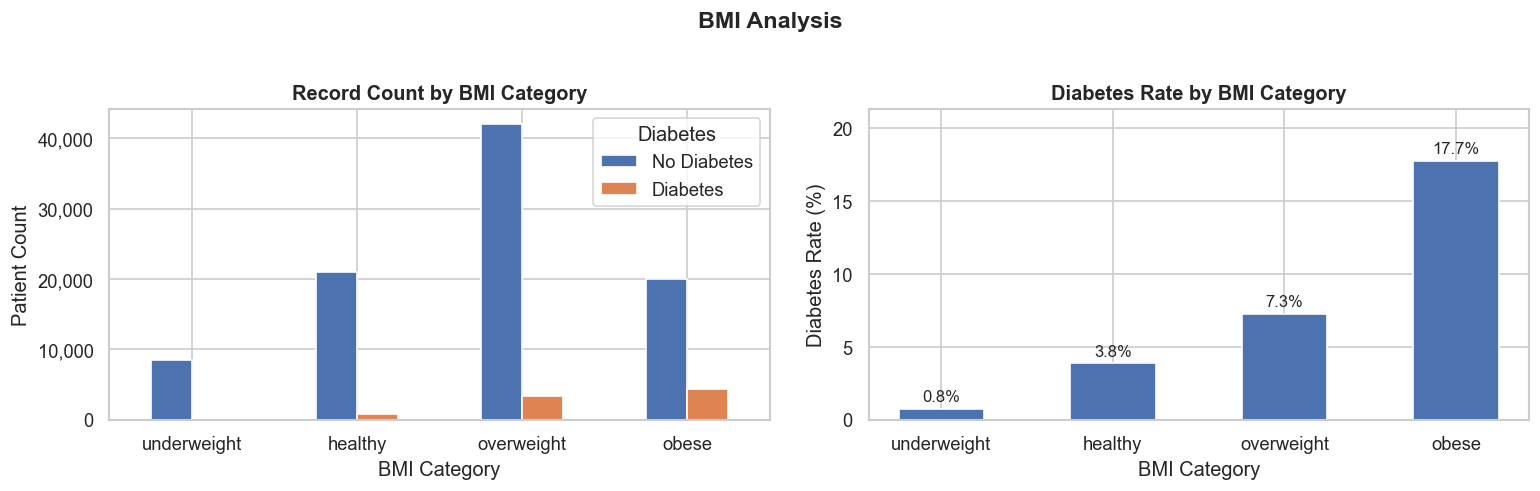

              total  diabetic       rate
bmi_category                            
underweight    8494        64   0.753473
healthy       21858       839   3.838412
overweight    45406      3295   7.256750
obese         24233      4299  17.740272


In [42]:
bmi_order = ["underweight", "healthy", "overweight", "obese"]

bmi_stats = (
    df.groupby("bmi_category")["diabetes"]
    .agg(total="count", diabetic="sum")
    .reindex(bmi_order)
)
bmi_stats["rate"] = bmi_stats["diabetic"] / bmi_stats["total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: grouped bar — counts per class
ct = df.groupby(["bmi_category", "diabetes"]).size().unstack(fill_value=0).reindex(bmi_order)
ct.columns = ["No Diabetes", "Diabetes"]
ct.plot(kind="bar", ax=axes[0], color=COLORS, edgecolor="white", rot=0)
axes[0].set_title("Record Count by BMI Category", fontsize=12, fontweight="bold")
axes[0].set_xlabel("BMI Category")
axes[0].set_ylabel("Patient Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend(title="Diabetes")

# Right: diabetes rate per BMI category
bars = axes[1].bar(bmi_order, bmi_stats["rate"], color="#4C72B0", edgecolor="white", width=0.5)
for bar, rate in zip(bars, bmi_stats["rate"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{rate:.1f}%", ha="center", va="bottom", fontsize=10)
axes[1].set_title("Diabetes Rate by BMI Category", fontsize=12, fontweight="bold")
axes[1].set_xlabel("BMI Category")
axes[1].set_ylabel("Diabetes Rate (%)")
axes[1].set_ylim(0, bmi_stats["rate"].max() * 1.2)

plt.suptitle("BMI Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "bmi_analysis.png"), bbox_inches="tight")
plt.show()

print(bmi_stats.to_string())

### 4.3 Comorbidity — Hypertension, Heart Disease & Combined Risk

Patients are grouped into four comorbidity tiers based on the presence of hypertension and heart disease. The combined flag (`both_conditions`) is also engineered as a binary `comorbidity` feature in `feature_engineering.py`.

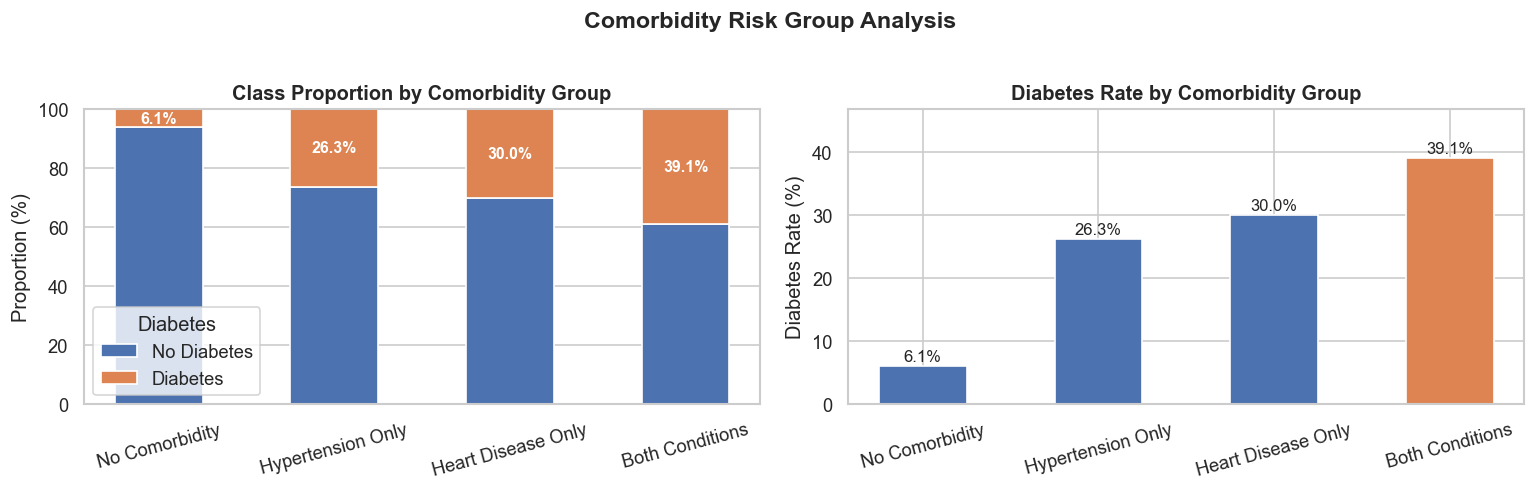

                    total  diabetic       rate
risk_group                                    
no_comorbidity      89480      5500   6.146625
hypertension_only    6569      1730  26.335820
heart_disease_only   3026       909  30.039656
both_conditions       916       358  39.082969


In [43]:
df["comorbidity"] = ((df["hypertension"] == 1) & (df["heart_disease"] == 1)).astype(int)

risk_order = ["no_comorbidity", "hypertension_only", "heart_disease_only", "both_conditions"]
risk_labels = ["No Comorbidity", "Hypertension Only", "Heart Disease Only", "Both Conditions"]

df["risk_group"] = df.apply(lambda r:
    "both_conditions"    if r["hypertension"] == 1 and r["heart_disease"] == 1 else
    "hypertension_only"  if r["hypertension"] == 1 else
    "heart_disease_only" if r["heart_disease"] == 1 else
    "no_comorbidity", axis=1
)

risk_stats = (
    df.groupby("risk_group")["diabetes"]
    .agg(total="count", diabetic="sum")
    .reindex(risk_order)
)
risk_stats["rate"]        = risk_stats["diabetic"] / risk_stats["total"] * 100
risk_stats["non_diabetic"] = 100 - risk_stats["rate"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: 100% stacked bar
axes[0].bar(risk_labels, risk_stats["non_diabetic"], color=COLORS[0],
            edgecolor="white", width=0.5, label="No Diabetes")
axes[0].bar(risk_labels, risk_stats["rate"], bottom=risk_stats["non_diabetic"],
            color=COLORS[1], edgecolor="white", width=0.5, label="Diabetes")
for i, rate in enumerate(risk_stats["rate"]):
    axes[0].text(i, 100 - rate / 2, f"{rate:.1f}%",
                 ha="center", va="center", fontsize=9.5,
                 color="white", fontweight="bold")
axes[0].set_title("Class Proportion by Comorbidity Group", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Proportion (%)")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(title="Diabetes")

# Right: diabetes rate per risk group
bar_colors = ["#4C72B0", "#4C72B0", "#4C72B0", "#DD8452"]
bars = axes[1].bar(risk_labels, risk_stats["rate"], color=bar_colors, edgecolor="white", width=0.5)
for bar, rate in zip(bars, risk_stats["rate"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{rate:.1f}%", ha="center", va="bottom", fontsize=10)
axes[1].set_title("Diabetes Rate by Comorbidity Group", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Diabetes Rate (%)")
axes[1].set_ylim(0, risk_stats["rate"].max() * 1.2)
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Comorbidity Risk Group Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "comorbidity_analysis.png"), bbox_inches="tight")
plt.show()

print(risk_stats[["total", "diabetic", "rate"]].to_string())

## 5. Geographic Distribution

Location is not a model feature but gives a real-world context to where the data was collected. The chart below shows the top 15 U.S. states by diabetes prevalence rate.

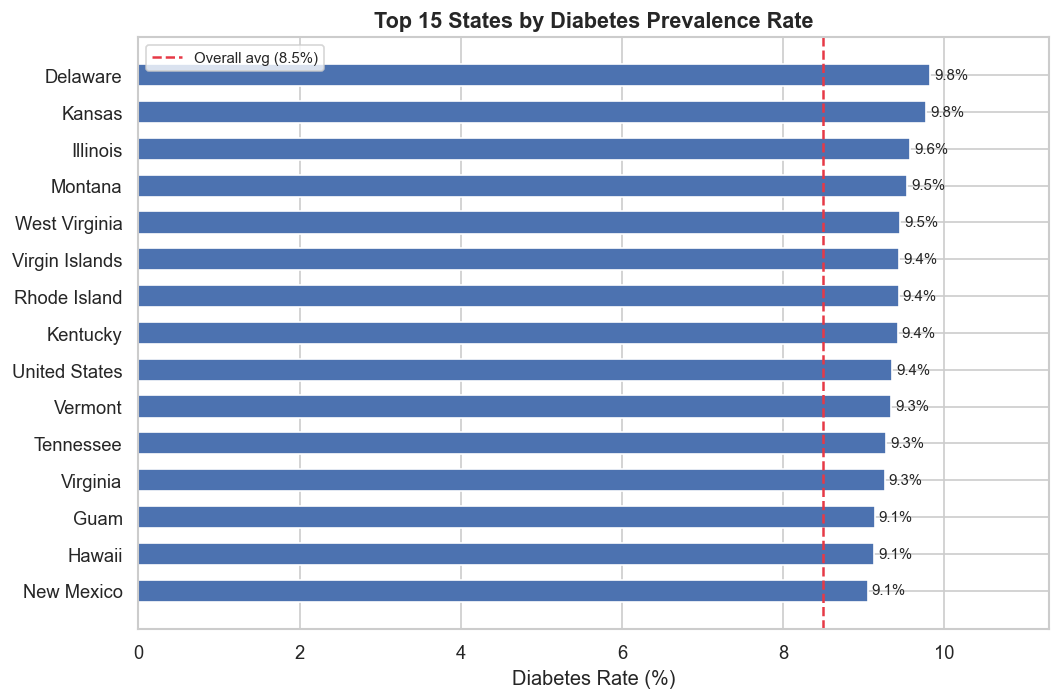

In [44]:
loc_stats = (
    raw.groupby("location")["diabetes"]
    .agg(total="count", diabetic="sum")
)
loc_stats["rate"] = loc_stats["diabetic"] / loc_stats["total"] * 100
top15 = loc_stats.sort_values("rate", ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15.index, top15["rate"], color="#4C72B0", edgecolor="white", height=0.6)
for bar, rate in zip(bars, top15["rate"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}%", va="center", fontsize=9)
ax.axvline(raw["diabetes"].mean() * 100, color="#e63946", linewidth=1.5,
           linestyle="--", label=f"Overall avg ({raw['diabetes'].mean()*100:.1f}%)")
ax.set_title("Top 15 States by Diabetes Prevalence Rate", fontsize=13, fontweight="bold")
ax.set_xlabel("Diabetes Rate (%)")
ax.set_xlim(0, top15["rate"].max() * 1.15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "geographic_distribution.png"), bbox_inches="tight")
plt.show()

## Conclusion

This overview examined the 100,000-record diabetes clinical dataset across its key dimensions before any machine learning is applied. The following findings shaped the design of the pipeline.

**Data Quality**
The dataset is clean with no missing values across all 16 columns. A minimal quality filter removed 9 records with out of range BMI values, leaving 99,991 records for modelling.

**Class Imbalance**
The dataset is heavily imbalanced at 10.8:1 (non-diabetic : diabetic), with diabetic patients making up only 8.5% of records. This is addressed in the pipeline through class weighting during model training rather than resampling, to preserve the natural population distribution.

**Strongest Risk Signals**
- **Age**: seniors (60+) carry the highest diabetes rate, driven by cumulative metabolic risk over time.
- **BMI**: diabetes rate rises consistently from underweight through to obese, with obese patients showing the sharpest increase.
- **Comorbidity**: patients with both hypertension and heart disease have a ~39% diabetes rate, nearly 6× the baseline. Even a single comorbidity more than triples the risk compared to no comorbidity.

**Feature Selection**
`hbA1c_level` and `blood_glucose_level` were deliberately excluded from the model despite being strong class separators. Both are direct diagnostic criteria for diabetes, including them would constitute data leakage. The pipeline instead uses age, BMI, hypertension, and heart disease: observable risk factors available before any lab test is ordered.

**Geography**
Diabetes prevalence varies modestly across states, with top states sitting around 1–2 percentage points above the national average. Location was not included as a model feature given the marginal signal.